# Programa para Realizar Aprendizaje Supervisado

## Etapa 1: Entendimiento de los datos

In [111]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import validation_curve
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import seaborn as sns
from sklearn.metrics import make_scorer
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import kagglehub
import os, glob

In [112]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Path to dataset files:", path)

csv = glob.glob(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))[0]
df = pd.read_csv(csv)
df.head()

Path to dataset files: C:\Users\workw\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [113]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [114]:
print(df.dtypes)
print(f"shape: {df.shape}")

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
shape: (7043, 21)


In [115]:
print("\nDistribución de Churn:")
print(df["Churn"].value_counts())


Distribución de Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [116]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [117]:
#Transformar
df["SeniorCitizen"] = df["SeniorCitizen"].astype("str")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [118]:
df.loc[df["TotalCharges"]==0, "TotalCharges"]

Series([], Name: TotalCharges, dtype: float64)

{'whiskers': [<matplotlib.lines.Line2D at 0x1e64dd24830>,
 'caps': [<matplotlib.lines.Line2D at 0x1e64dd24ad0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e64dd246e0>,
 'medians': [<matplotlib.lines.Line2D at 0x1e64dd24d70>,
 'fliers': [<matplotlib.lines.Line2D at 0x1e64dd24ec0>,
 'means': []}

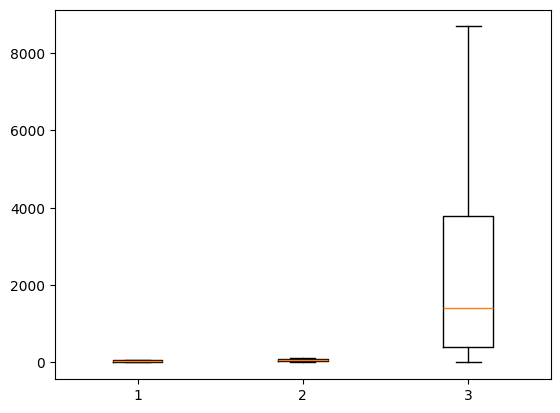

In [119]:
plt.boxplot((df['tenure'],df['MonthlyCharges'],df["TotalCharges"]))

In [120]:
resumen = pd.concat(
    [df['tenure'].describe(), df['MonthlyCharges'].describe(),df['TotalCharges'].describe()],
    axis=1
)

print(resumen)

            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2281.916928
std      24.559481       30.090047   2265.270398
min       0.000000       18.250000     18.800000
25%       9.000000       35.500000    402.225000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000


## Etapa 2: Preparación de los datos

In [121]:
#Train-test split
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]
numerica = X.select_dtypes(include=["number"]).columns.tolist()
categorica = X.select_dtypes(exclude=["number"]).columns.tolist() 

In [122]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [123]:
prepo_num_var = Pipeline(
    [
        ("scaler", StandardScaler()),
    ]
)
prepo_cat_var = Pipeline(
    [
        ("onehot",OneHotEncoder()),
    ]
)

In [124]:
prepo= ColumnTransformer(
    [
        ("numeric preprocessing", prepo_num_var, numerica),
        ("caregorical pre-processing", prepo_cat_var, categorica)
        ,
    ]
)
prepo

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric preprocessing', ...), ('caregorical pre-processing', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transf

## Etapa 3: Modelo
### Random Forest

In [125]:
model = Pipeline(
    [
        ("pre-processing", prepo),
        ("balanceo", RandomUnderSampler(random_state=42)),
        ("random_forest", RandomForestClassifier(n_estimators=150,random_state=42)),
    ]
)
model

,steps,"[('pre-processing', ...), ('balanceo', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric preprocessing', ...), ('caregorical pre-processing', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``,

In [126]:
model.fit(X_train,y_train)

,steps,"[('pre-processing', ...), ('balanceo', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric preprocessing', ...), ('caregorical pre-processing', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``,

In [127]:
y_pred_test = model.predict(X_test)
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

          No       0.90      0.73      0.81      1036
         Yes       0.51      0.77      0.62       373

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409



In [128]:
f1_score(y_test,y_pred_test,pos_label="Yes")

0.6168623265741728

In [129]:
param_range = [50, 100, 150, 200, 300, 400, 500]

train_scores, test_scores = validation_curve(
    model,
    X_train,
    y_train,
    param_name="random_forest__n_estimators",
    param_range=param_range,
    scoring=make_scorer(f1_score, pos_label="Yes"),
    cv=5,
    n_jobs=-1
)

In [130]:
test_scores

array([[0.61417323, 0.60387812, 0.61454047, 0.58792651, 0.60356653],
       [0.62204724, 0.60458839, 0.61455526, 0.57901726, 0.61917808],
       [0.62938882, 0.61268556, 0.6147651 , 0.58355438, 0.61917808],
       [0.62256809, 0.61290323, 0.60540541,        nan, 0.61369863],
       [0.62694301, 0.6147651 ,        nan, 0.59894459, 0.61058345],
       [0.61794872, 0.61126005, 0.61208054, 0.59733333, 0.61307902],
       [0.61261261, 0.6155914 , 0.60834455, 0.5986755 , 0.6097561 ]])

Text(0, 0.5, 'f1_score')

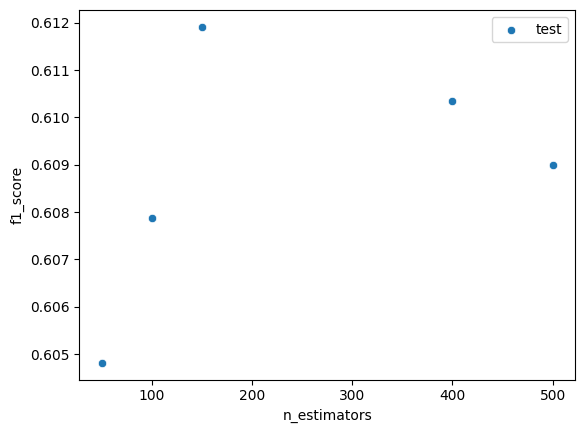

In [131]:
sns.scatterplot(x=param_range, y=test_scores.mean(axis=1), label="test")
plt.xlabel("n_estimators")
plt.ylabel("f1_score")

### Suport Vector Machine

In [132]:
model = Pipeline(
    [
        ("pre-processing", prepo),
        ("balanceo", RandomUnderSampler(random_state=42)),
        ("SVM", SVC(C=1,kernel='rbf',random_state=42)),
    ]
)
model
model.fit(X_train,y_train)
y_pred_test = model.predict(X_test)
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

          No       0.92      0.73      0.82      1036
         Yes       0.53      0.82      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [133]:
f1_score(y_test,y_pred_test,pos_label="Yes")

0.6408376963350786

In [134]:
param_range = [0.01, 0.1, 1, 10, 100]

train_scores, test_scores = validation_curve(
    model,
    X_train,
    y_train,
    param_name="SVM__C",
    param_range=param_range,
    scoring=make_scorer(f1_score, pos_label="Yes"),
    cv=5,
    n_jobs=-1
)

In [135]:
test_scores

array([[0.62967742, 0.59865772, 0.60427807, 0.58638743, 0.61021505],
       [0.63131313, 0.6113307 , 0.61192053, 0.60746461, 0.60483871],
       [0.6490566 , 0.61744966, 0.60653595, 0.59230769, 0.61891892],
       [0.60598504, 0.59278351, 0.58762887, 0.58205128, 0.58666667],
       [0.556804  , 0.53367217, 0.54961832, 0.52835052, 0.55886158]])

Text(0, 0.5, 'f1_score')

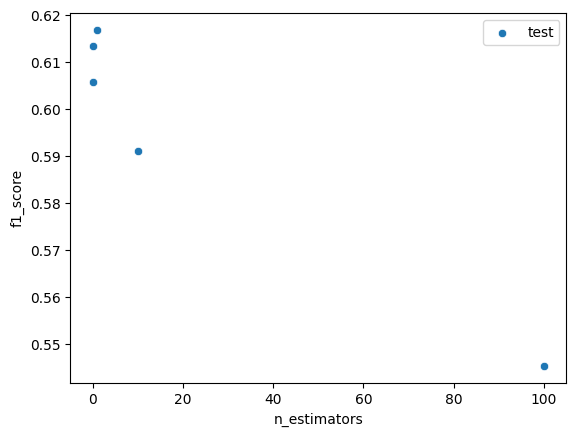

In [136]:
sns.scatterplot(x=param_range, y=test_scores.mean(axis=1), label="test")
plt.xlabel("n_estimators")
plt.ylabel("f1_score")